In [1]:
import cdms
import numpy as np
import os, sys 
import ROOT
from cats.cdataframe import CDataFrame
from CDMSDataCatalog import CDMSDataCatalog
import supercuts
import glob

import matplotlib.pyplot as plt
%matplotlib inline

CDMS = os.environ["CDMS"] # set in .bash_profile
stylesheet = os.path.join(CDMS,"scripts","stylesheets","blues.mplstyle")
plt.style.use(stylesheet)

sys.path.append(os.path.join(os.path.join(CDMS,"scripts")))
import setup

Welcome to JupyROOT 6.28/10


In [2]:
from scipy.optimize import curve_fit
from uncertainties import ufloat
import math

def func(x, a, b):
    return a*x + b

def fit_logPulse(x, y, start, stop):
    popt, pcov = curve_fit(func, x[start:stop], y[start:stop])
    return popt[0], np.sqrt(np.diag(pcov))[0], popt[1], np.sqrt(np.diag(pcov))[1]

def str_with_err(value, error):
    digits = -int(math.floor(math.log10(error)))
    return "{0:.{2}f}({1:.0f})".format(value, error*10**digits, digits)

In [3]:
# Z1 low bg 50V
series_list=['23240109_075338', '23240109_021236', 
'23240108_203134', '23231221_101235', 
'23231221_015705', '23231220_190923', 
'23231220_122140', '23231220_053358', 
'23231220_012745', '23231219_184002', 
'23231219_110331', '23231219_034952', 
'23231218_223530', '23231218_190035', 
'23231218_152721', '23231218_093255', 
'23231218_024511', '23231217_212512', 
'23231217_171613', 
'23231217_135018', '23231216_233807', 
'23231216_211119', '23231216_194929', 
'23231216_182937', '23231216_173436', 
'23231216_145300', '23231216_100125', 
'23231216_043946', '23231216_013604'] # Ge calibration  

In [4]:
ProdTag = 'CUTE_T3GeCalib_NxM_P4.0.0_V05-06_C0.3.6'

In [5]:
filepath = [f'/scratch/perry/CDMS/CUTE/R37/Processed/Releases/{ProdTag}/Submerged/{ProdTag}_{i}.root' for i in series_list]

In [6]:
det = 1 # detector number

df = CDataFrame("rqDir/zip"+str(det), filepath, friends = [[x+":rqDir/eventTree" for x in filepath]])

In [7]:
## Apply some basic data quality filters and get the RQs you're interested in
logfile = '"cute_tower3testing.log"'
df = df.Define("LEDLogFile", logfile) 
df = df.CDefine("LEDOn", supercuts.ledOn_old, ["EventTime", "LEDLogFile"])
df = df.Filter("!LEDOn")
df_filtered = df.Filters(["TriggerType == 1", "TriggerDetectorNum=="+str(det), "PTOFamps>0"])

In [8]:
RQs = (["SeriesNumber", "PTOFamps", "PTINTall", "EventNumber", "EventTime"])
df_rqs = df_filtered.AsNumpy(RQs)

In [9]:
def linearize(x):
    return 1/b * (np.exp(x / a) - 1)

def pt2keV(x):
    lin_pt = linearize(x)
    recoilE = lin_pt * calibFac / LukeFac
    return recoilE

In [10]:
a, b = 2.08e-04, 1.63e+01
calibFac = 21000
LukeFac = 1 + 50 / 3
df_rqs['PTOFamps_keVee'] = pt2keV(df_rqs['PTOFamps'])

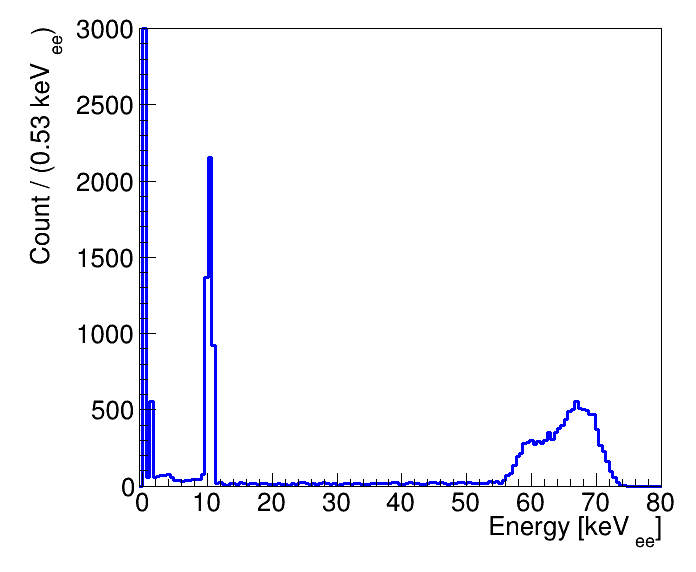

In [11]:
ROOT.gStyle.SetOptStat(0)
bins_start = 0
bins_end = 80
nbins = 150
bindiff = np.round((bins_end - bins_start) / nbins, 2)

# Create a ROOT histogram: (name, title, nbins, xmin, xmax)
h = ROOT.TH1F("h", ";Energy [keV_{ee}];Count / (" + str(bindiff) + " keV_{ee})", nbins, bins_start, bins_end)
data = df_rqs['PTOFamps_keVee']

for value in data:
    h.Fill(value)
h.SetLineWidth(3)
h.SetLineColor(ROOT.kBlue)
    
h.SetMinimum(0)
h.SetMaximum(3000)
h.GetXaxis().SetLabelSize(0.05)
h.GetYaxis().SetLabelSize(0.05)
h.GetXaxis().SetTitleSize(0.05)
h.GetYaxis().SetTitleSize(0.05)
h.GetXaxis().SetRangeUser(-30, 80)

c = ROOT.TCanvas("c", "Canvas", 700, 600)
c.SetLeftMargin(0.2)
c.SetBottomMargin(0.15)
c.SetRightMargin(0.05)
c.SetTopMargin(0.05)
h.Draw()
c.Draw()

Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c


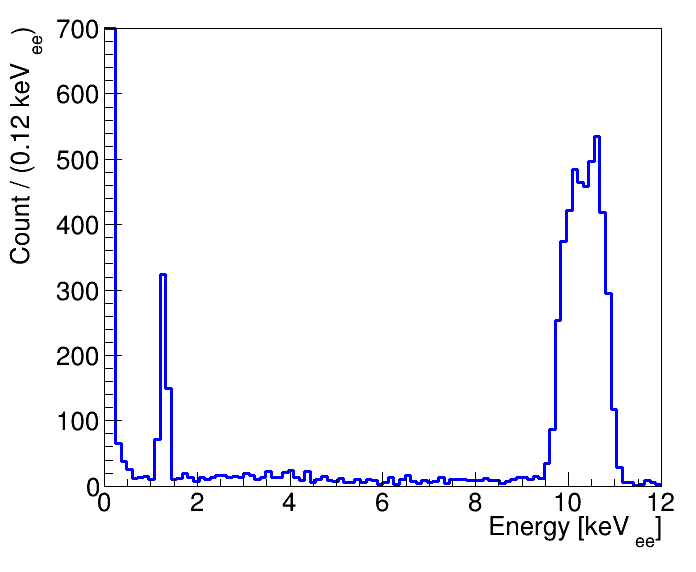

In [12]:
ROOT.gStyle.SetOptStat(0)
bins_start = 0
bins_end = 12
nbins = 100
bindiff = np.round((bins_end - bins_start) / nbins, 2)

# Create a ROOT histogram: (name, title, nbins, xmin, xmax)
h = ROOT.TH1F("h", ";Energy [keV_{ee}];Count / (" + str(bindiff) + " keV_{ee})", nbins, bins_start, bins_end)
data = df_rqs['PTOFamps_keVee']

# Fill the histogram with data from the NumPy array
for value in data:
    h.Fill(value)
h.SetLineWidth(3)  # Thicker line
h.SetLineColor(ROOT.kBlue)
    
h.SetMinimum(0)
h.SetMaximum(700)  # Adjust based on your data
h.GetXaxis().SetLabelSize(0.05)
h.GetYaxis().SetLabelSize(0.05)
h.GetXaxis().SetTitleSize(0.05)
h.GetYaxis().SetTitleSize(0.05)
#h.GetXaxis().SetRangeUser(-2, 35)

# Draw the histogram
c = ROOT.TCanvas("c", "Canvas", 700, 600)
c.SetLeftMargin(0.15)
c.SetBottomMargin(0.15)
c.SetRightMargin(0.05)
c.SetTopMargin(0.05)
h.Draw()
c.Draw()

Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c


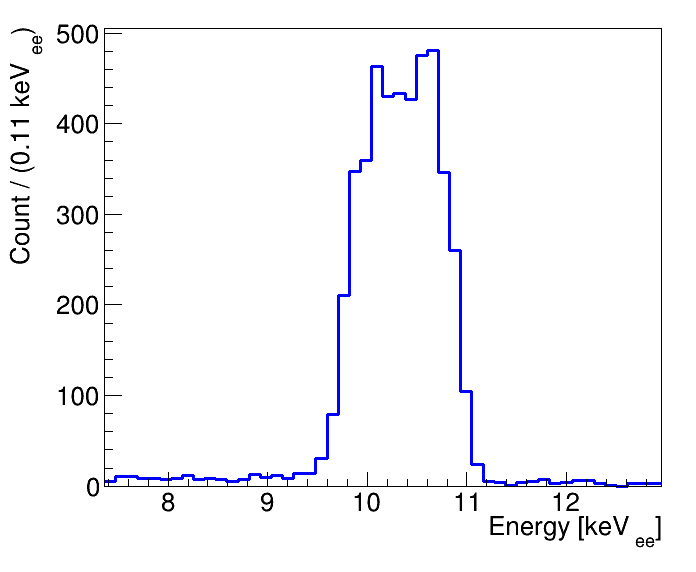

In [13]:
ROOT.gStyle.SetOptStat(0)
bins_start = pt2keV(20e-6)
bins_end = pt2keV(34e-6)
nbins = 50
bindiff = np.round((bins_end - bins_start) / nbins, 2)

# Create a ROOT histogram: (name, title, nbins, xmin, xmax)
h = ROOT.TH1F("h", ";Energy [keV_{ee}];Count / (" + str(bindiff) + " keV_{ee})", nbins, bins_start, bins_end)
data = df_rqs['PTOFamps_keVee']

# Fill the histogram with data from the NumPy array
for value in data:
    h.Fill(value)
h.SetLineWidth(3)  # Thicker line
h.SetLineColor(ROOT.kBlue)
    
h.SetMinimum(0)
#h.SetMaximum(700)  # Adjust based on your data
h.GetXaxis().SetLabelSize(0.05)
h.GetYaxis().SetLabelSize(0.05)
h.GetXaxis().SetTitleSize(0.05)
h.GetYaxis().SetTitleSize(0.05)
#h.GetXaxis().SetRangeUser(-2, 35)

# Draw the histogram
c = ROOT.TCanvas("c", "Canvas", 700, 600)
c.SetLeftMargin(0.15)
c.SetBottomMargin(0.15)
c.SetRightMargin(0.05)
c.SetTopMargin(0.05)
h.Draw()
c.Draw()

In [80]:
L_peak_data = df_rqs['PTOFamps_keVee'][(df_rqs['PTOFamps_keVee'] >= 0.85) & (df_rqs['PTOFamps_keVee'] <= 1.7)]
K_peak_data = df_rqs['PTOFamps_keVee'][(df_rqs['PTOFamps_keVee'] >= pt2keV(20e-6)) & (df_rqs['PTOFamps_keVee'] <= pt2keV(34e-6))]

 **********
 **   13 **SET PRINT           1
 **********
 **********
 **   14 **SET NOGRAD
 **********
 PARAMETER DEFINITIONS:
    NO.   NAME         VALUE      STEP SIZE      LIMITS
     1 #mu1         1.28000e+00  2.00000e-02    1.20000e+00  1.40000e+00
     2 #sigma1      1.75000e-01  1.25000e-02    1.00000e-02  2.00000e-01
     3 frac         8.70000e-01  6.50000e-02    0.00000e+00  1.00000e+00
 **********
 **   15 **SET ERR         0.5
 **********
 **********
 **   16 **SET PRINT           1
 **********
 **********
 **   17 **SET STR           1
 **********
 NOW USING STRATEGY  1: TRY TO BALANCE SPEED AGAINST RELIABILITY
 **********
 **   18 **MIGRAD        1500           1
 **********
 FIRST CALL TO USER FUNCTION AT NEW START POINT, WITH IFLAG=4.
 START MIGRAD MINIMIZATION.  STRATEGY  1.  CONVERGENCE WHEN EDM .LT. 1.00e-03
 FCN=-551.983 FROM MIGRAD    STATUS=INITIATE       29 CALLS          30 TOTAL
                     EDM= unknown      STRATEGY= 1      NO ERROR MATRIX       
  

Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c


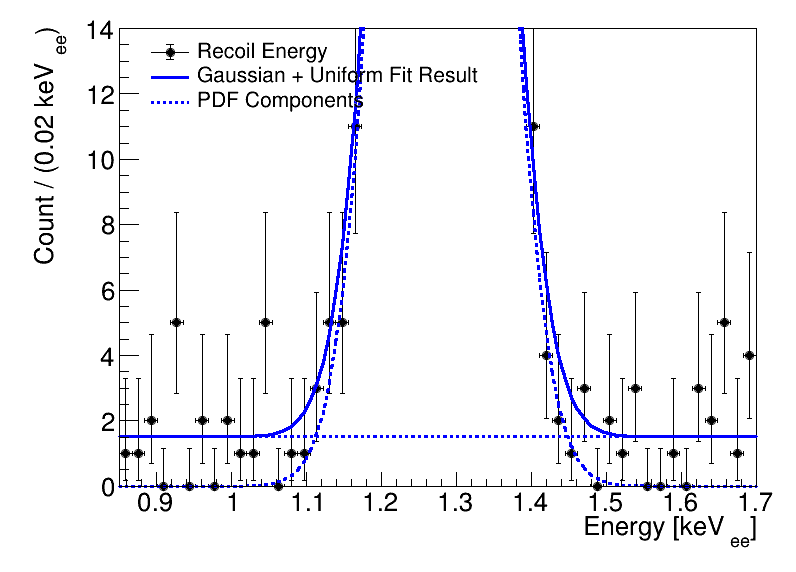

In [86]:
ROOT.gStyle.SetOptStat(0)
bins_start = 0.85
bins_end = 1.7
nbins = 50
bindiff = np.round((bins_end - bins_start) / nbins, 2)

# Create a ROOT histogram: (name, title, nbins, xmin, xmax)
h = ROOT.TH1F("h", ";Energy [keV_{ee}];Count / (" + str(bindiff) + " keV_{ee})", nbins, bins_start, bins_end)
data = df_rqs['PTOFamps_keVee']

# Fill the histogram with data from the NumPy array
for value in data:
    h.Fill(value)

x = ROOT.RooRealVar("x", "x", bins_start, bins_end)  # use your histogram's x range

mean = ROOT.RooRealVar("#mu1", "#mu", 1.28, 1.2, 1.4)
sigma = ROOT.RooRealVar("#sigma1", "#sigma", 0.175, 0.01, 0.2)
gauss = ROOT.RooGaussian("gauss", "Gaussian PDF", x, mean, sigma)

flat = ROOT.RooUniform("flat", "Uniform PDF", x)

frac = ROOT.RooRealVar("frac", "signal fraction", 0.87, 0.0, 1.0)

model = ROOT.RooAddPdf("model", "gauss + flat", ROOT.RooArgList(gauss, flat), ROOT.RooArgList(frac))
data = ROOT.RooDataHist("data", "binned data", ROOT.RooArgList(x), h)

#fit_result = model.fitTo(data)  # binned by default for RooDataHist
nll = model.createNLL(data)
m = ROOT.RooMinimizer(nll)
m.migrad()

fit_result = m.save()

frame = x.frame(ROOT.RooFit.Title(" "))
# Change axis labels
frame.GetXaxis().SetTitle("Energy [keV_{ee}]")
frame.GetYaxis().SetTitle(f"Count / (" + str(bindiff) + " keV_{ee})")
frame.GetXaxis().SetLabelSize(0.05)
frame.GetYaxis().SetLabelSize(0.05)
frame.GetXaxis().SetTitleSize(0.05)
frame.GetYaxis().SetTitleSize(0.05)

data.plotOn(frame, ROOT.RooFit.Name("Recoil Energy"))
model.plotOn(frame, ROOT.RooFit.Name("Gaussian + Uniform Fit Result"))
model.plotOn(frame, ROOT.RooFit.Components("gauss"), ROOT.RooFit.LineStyle(ROOT.kDashed), ROOT.RooFit.LineColor(ROOT.kBlue), ROOT.RooFit.Name("PDF Components"))
model.plotOn(frame, ROOT.RooFit.Components("flat"), ROOT.RooFit.LineStyle(ROOT.kDashed), ROOT.RooFit.LineColor(ROOT.kBlue))

# Create legend
legend = ROOT.TLegend(0.18, 0.8, 0.45, 0.93)
legend.SetBorderSize(0)
legend.SetFillStyle(0)

# Add entries by retrieving plotted objects by name
legend.AddEntry(frame.findObject("Recoil Energy"),  "Recoil Energy", "lep")
legend.AddEntry(frame.findObject(f"Gaussian + Uniform Fit Result"), f"Gaussian + Uniform Fit Result", "l")
legend.AddEntry(frame.findObject("PDF Components"), "PDF Components", "l")
legend.SetTextSize(0.04)

frame.SetMinimum(0)
#frame.SetMaximum(85)  # Adjust based on your data
frame.SetMaximum(14)  # Adjust based on your data
    
c = ROOT.TCanvas("c", "Fit Canvas", 800, 600)
c.SetLeftMargin(0.15)
c.SetBottomMargin(0.15)
c.SetRightMargin(0.05)
c.SetTopMargin(0.05)
frame.Draw()
legend.Draw()
c.Draw()

In [82]:
nevent = ROOT.RooRealVar("#nevent", "#number of fitted events", len(L_peak_data))
signal = ROOT.RooProduct("event yield", "nevent * frac", ROOT.RooArgList(nevent, frac))

print(f'The number of events in the peak is {signal.getVal():.1f} with error {signal.getPropagatedError(fit_result):.1f}')

The number of events in the peak is 516.5 with error 11.0


In [106]:
upper_bound = ROOT.RooFormulaVar("upperBound", "@0 + 3 * @1", ROOT.RooArgList(mean, sigma))
lower_bound = ROOT.RooFormulaVar("lowerBound", "@0 - 3 * @1", ROOT.RooArgList(mean, sigma))

In [107]:
uniform_norm = ROOT.RooFormulaVar("norm", "1 - @0", ROOT.RooArgList(frac))
nevent = ROOT.RooRealVar("#nevent", "#number of fitted events", len(L_peak_data))
binwidth = ROOT.RooRealVar("#binwidth", "#binwidth", (bins_end - bins_start) / nbins)
uniform_height = ROOT.RooRealVar("#height", "#height", 1 / (bins_end - bins_start))

uniform_count = ROOT.RooProduct("#count", "(1 - frac1) * nevent * binwidth * 1 / (range)", ROOT.RooArgList(uniform_norm, nevent, binwidth, uniform_height))

In [108]:
uniform_magnitude = uniform_count.getVal() # count / bin
uniform_magnitude_err = uniform_count.getPropagatedError(fit_result) # count / bin
upper_range = upper_bound.getVal()
lower_range = lower_bound.getVal()
fitted_bins = (upper_range - lower_range) / ((bins_end - bins_start) / nbins)

In [109]:
integrated_uniform = uniform_magnitude * fitted_bins
integrated_uniform_err = uniform_magnitude_err * fitted_bins

In [110]:
rangeCut = (df_rqs['PTOFamps_keVee'] >= lower_bound.getVal()) & (df_rqs['PTOFamps_keVee'] <= upper_bound.getVal())

In [114]:
sum(rangeCut)

549

In [115]:
integrated_uniform

33.31634265863719

In [111]:
sum(rangeCut) - integrated_uniform

515.6836573413628

In [113]:
integrated_uniform_err

4.839592570301601

 **********
 **    1 **SET PRINT           1
 **********
 **********
 **    2 **SET NOGRAD
 **********
 PARAMETER DEFINITIONS:
    NO.   NAME         VALUE      STEP SIZE      LIMITS
     1 #mu1         1.00363e+01  1.19473e-01    9.31354e+00  1.05083e+01
     2 #mu2         1.05083e+01  1.20627e-01    1.01081e+01  1.13144e+01
     3 #sigma1      1.86056e-01  3.16377e-02    3.50686e-02  3.51446e-01
     4 #sigma2      1.68483e-01  3.16377e-02    3.50686e-02  3.51446e-01
     5 c           -2.00000e+01  1.00000e+01   -1.00000e+02  0.00000e+00
     6 c1           4.30000e-01  1.00000e-01    0.00000e+00  1.00000e+00
     7 c2           3.80000e-01  1.00000e-01    0.00000e+00  1.00000e+00
     8 c3           1.00000e-01  5.00000e-02    0.00000e+00  1.00000e+00
     9 m0           9.63839e+00  4.75825e-02    9.31354e+00  9.78936e+00
 **********
 **    3 **SET ERR         0.5
 **********
 **********
 **    4 **SET PRINT           1
 **********
 **********
 **    5 **SET STR           1
 ****

Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).


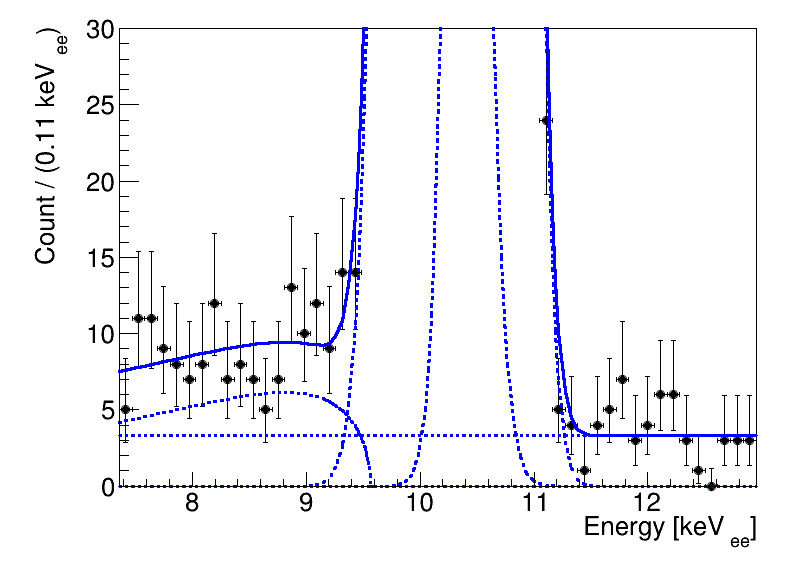

In [116]:
ROOT.gStyle.SetOptStat(0)
bins_start = pt2keV(20e-6)
bins_end = pt2keV(34e-6)
nbins = 50
bindiff = np.round((bins_end - bins_start) / nbins, 2)

# Create a ROOT histogram: (name, title, nbins, xmin, xmax)
h = ROOT.TH1F("h", ";Energy [keV_{ee}];Count / (" + str(bindiff) + " keV_{ee})", nbins, bins_start, bins_end)
data = df_rqs['PTOFamps_keVee']

# Fill the histogram with data from the NumPy array
for value in data:
    h.Fill(value)

x = ROOT.RooRealVar("x", "x", bins_start, bins_end)  # use your histogram's x range

# Parameters
mean_1 = ROOT.RooRealVar("#mu1", "#mu", pt2keV(26.82e-6), pt2keV(25e-6), pt2keV(28e-6))
sigma_1 = ROOT.RooRealVar("#sigma1", "#sigma", pt2keV(0.53e-6), pt2keV(0.1e-6), pt2keV(1e-6))
mean_2 = ROOT.RooRealVar("#mu2", "#mu", pt2keV(28e-6), pt2keV(27e-6), pt2keV(30e-6))
sigma_2 = ROOT.RooRealVar("#sigma2", "#sigma", pt2keV(0.48e-6), pt2keV(0.1e-6), pt2keV(1e-6))

# Distributions
g1 = ROOT.RooGaussian("g1", "#g1", x, mean_1, sigma_1)
g2 = ROOT.RooGaussian("g2", "#g2", x, mean_2, sigma_2)

flat = ROOT.RooUniform("flat", "#flat", x)

# Argus background (left-side tail)
m0   = ROOT.RooRealVar("m0", "Endpoint", pt2keV(25.82e-6), pt2keV(25e-6), pt2keV(26.2e-6))  # same as Gaussian mean
c    = ROOT.RooRealVar("c", "Curvature", -20.0, -100.0, 0.0)
argus = ROOT.RooArgusBG("argus", "Argus Tail", x, m0, c)

# Weight of distributions
frac1 = ROOT.RooRealVar("c1", "#c", 0.43, 0.0, 1.0)
frac2 = ROOT.RooRealVar("c2", "#c", 0.38, 0.0, 1.0)
frac3 = ROOT.RooRealVar("c3", "#c", 0.1, 0.0, 1.0)
#frac4 = ROOT.RooRealVar("c4", "#c", 0.15, 0.0, 1.0)

# Convert numpy array into RooFit object
model = ROOT.RooAddPdf("model", "model", ROOT.RooArgList(g1, g2, argus, flat), ROOT.RooArgList(frac1, frac2, frac3))
data = ROOT.RooDataHist("data", "binned data", ROOT.RooArgList(x), h)

#fit_result = model.fitTo(data)  # binned by default for RooDataHist
nll = model.createNLL(data)
m = ROOT.RooMinimizer(nll)
m.migrad()

fit_result = m.save()

frame = x.frame(ROOT.RooFit.Title(" "))
# Change axis labels
frame.GetXaxis().SetTitle("Energy [keV_{ee}]")
frame.GetYaxis().SetTitle(f"Count / (" + str(bindiff) + " keV_{ee})")
frame.GetXaxis().SetLabelSize(0.05)
frame.GetYaxis().SetLabelSize(0.05)
frame.GetXaxis().SetTitleSize(0.05)
frame.GetYaxis().SetTitleSize(0.05)

data.plotOn(frame, ROOT.RooFit.Name("Recoil Energy"))
model.plotOn(frame, ROOT.RooFit.Name(f"2 Gaussian + Uniform Fit Result"))
model.plotOn(frame, ROOT.RooFit.Components("g1"), ROOT.RooFit.LineStyle(ROOT.kDashed), ROOT.RooFit.LineColor(ROOT.kBlue), ROOT.RooFit.Name("PDF Components"))
model.plotOn(frame, ROOT.RooFit.Components("g2"), ROOT.RooFit.LineStyle(ROOT.kDashed), ROOT.RooFit.LineColor(ROOT.kBlue))
model.plotOn(frame, ROOT.RooFit.Components("argus"), ROOT.RooFit.LineStyle(ROOT.kDashed), ROOT.RooFit.LineColor(ROOT.kBlue))
model.plotOn(frame, ROOT.RooFit.Components("flat"), ROOT.RooFit.LineStyle(ROOT.kDashed), ROOT.RooFit.LineColor(ROOT.kBlue))

# Create legend
legend = ROOT.TLegend(0.18, 0.8, 0.45, 0.93)
legend.SetBorderSize(0)
legend.SetFillStyle(0)

# Add entries by retrieving plotted objects by name
legend.AddEntry(frame.findObject("Recoil Energy"),  "Recoil Energy", "lep")
legend.AddEntry(frame.findObject(f"2 Gaussian + Argus + Uniform Fit Result"), f"2 Gaussian + Argus + Uniform Fit Result", "l")
legend.AddEntry(frame.findObject("PDF Components"), "PDF Components", "l")
legend.SetTextSize(0.04)

frame.SetMinimum(0)
frame.SetMaximum(30)  # Adjust based on your data
#frame.SetMaximum(650)  # Adjust based on your data
    
c = ROOT.TCanvas("c", "Fit Canvas", 800, 600)
c.SetLeftMargin(0.15)
c.SetBottomMargin(0.15)
c.SetRightMargin(0.05)
c.SetTopMargin(0.05)
frame.Draw()
#legend.Draw()
c.Draw()

In [117]:
upper_bound = ROOT.RooFormulaVar("upperBound", "@0 + 3 * @1", ROOT.RooArgList(mean_2, sigma_2))
lower_bound = ROOT.RooFormulaVar("lowerBound", "@0 - 3 * @1", ROOT.RooArgList(mean_1, sigma_1))

In [118]:
uniform_norm = ROOT.RooFormulaVar("norm", "1 - @0 - @1 - @2", ROOT.RooArgList(frac1, frac2, frac3))
nevent = ROOT.RooRealVar("#nevent", "#number of fitted events", len(K_peak_data))
binwidth = ROOT.RooRealVar("#binwidth", "#binwidth", (bins_end - bins_start) / nbins)
uniform_height = ROOT.RooRealVar("#height", "#height", 1 / (bins_end - bins_start))

uniform_count = ROOT.RooProduct("#count", "(1 - frac1 - frac2 - frac3) * nevent * binwidth * 1 / (range)", ROOT.RooArgList(uniform_norm, nevent, binwidth, uniform_height))

In [119]:
uniform_magnitude = uniform_count.getVal() # count / bin
uniform_magnitude_err = uniform_count.getPropagatedError(fit_result) # count / bin
upper_range = upper_bound.getVal()
lower_range = lower_bound.getVal()
fitted_bins = (upper_range - lower_range) / ((bins_end - bins_start) / nbins)

In [120]:
integrated_uniform = uniform_magnitude * fitted_bins
integrated_uniform_err = uniform_magnitude_err * fitted_bins

In [121]:
rangeCut = (df_rqs['PTOFamps_keVee'] >= lower_bound.getVal()) & (df_rqs['PTOFamps_keVee'] <= upper_bound.getVal())

In [122]:
sum(rangeCut) 

4489

In [123]:
integrated_uniform

55.34826567637539

In [124]:
integrated_uniform_err

7.666553412441118

In [68]:
sum(rangeCut) - integrated_uniform

4433.651734323625